In [1]:
# Cell 1 — Load everything fresh
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv(r'C:\Users\dell\Desktop\FYP_Traffic\data\dft_traffic_counts_aadf.csv',
                 low_memory=False)

# Add HGV percentage feature
df['hgv_percentage'] = (df['all_HGVs'] / df['all_motor_vehicles']) * 100

print("✅ Data loaded!")
print(f"Shape: {df.shape}")

✅ Data loaded!
Shape: (555880, 35)


In [2]:
# Cell 2 — Encode categorical columns
le_road = LabelEncoder()
le_region = LabelEncoder()

df['road_category_enc'] = le_road.fit_transform(df['road_category'])
df['region_name_enc'] = le_region.fit_transform(df['region_name'])

print("✅ Encoding done!")
print("Road categories:", le_road.classes_)
print("Regions:", le_region.classes_)

✅ Encoding done!
Road categories: ['MB' 'MCU' 'PA' 'PM' 'TA' 'TM']
Regions: ['East Midlands' 'East of England' 'London' 'North East' 'North West'
 'Scotland' 'South East' 'South West' 'Wales' 'West Midlands'
 'Yorkshire and the Humber']


In [8]:
# Cell 3 — TRULY independent features only
# No vehicle count components at all

corrected_features = ['year',
                      'hgv_percentage',
                      'road_category_enc',
                      'region_name_enc']

target = 'all_motor_vehicles'

ml_df = df[corrected_features + [target]].dropna()

X = ml_df[corrected_features]
y = ml_df[target]

print(f"✅ Features ready!")
print(f"X shape: {X.shape}")
print(f"Features: {corrected_features}")

✅ Features ready!
X shape: (555857, 4)
Features: ['year', 'hgv_percentage', 'road_category_enc', 'region_name_enc']


In [9]:
# Cell 4 — Train test split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42)

print(f"✅ Data split done!")
print(f"Training set: {X_train.shape}")
print(f"Testing set:  {X_test.shape}")

✅ Data split done!
Training set: (444685, 4)
Testing set:  (111172, 4)


In [10]:
# Cell 5 — Train Random Forest
print("Training Random Forest... please wait...")

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1)

rf_model.fit(X_train, y_train)

print("✅ Training complete!")

Training Random Forest... please wait...
✅ Training complete!


In [11]:
# Cell 6 — Evaluate model
y_pred = rf_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=" * 50)
print("CORRECTED RANDOM FOREST RESULTS")
print("No data leakage — genuine prediction")
print("=" * 50)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")
print("=" * 50)

CORRECTED RANDOM FOREST RESULTS
No data leakage — genuine prediction
MAE  : 8068.89
RMSE : 13455.82
R²   : 0.5592


In [12]:
# Cell 7 — XGBoost corrected model
from xgboost import XGBRegressor

print("Training XGBoost... please wait...")

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1)

xgb_model.fit(X_train, y_train)
print("✅ XGBoost training complete!")

Training XGBoost... please wait...
✅ XGBoost training complete!


In [13]:
# Cell 8 — Evaluate XGBoost
y_pred_xgb = xgb_model.predict(X_test)

mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb   = r2_score(y_test, y_pred_xgb)

print("=" * 50)
print("XGBOOST CORRECTED RESULTS")
print("=" * 50)
print(f"MAE  : {mae_xgb:.2f}")
print(f"RMSE : {rmse_xgb:.2f}")
print(f"R²   : {r2_xgb:.4f}")
print("=" * 50)

XGBOOST CORRECTED RESULTS
MAE  : 8063.34
RMSE : 13111.35
R²   : 0.5815


In [14]:
# Cell 9 — Full comparison
import pandas as pd

results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'MAE':   [mae, mae_xgb],
    'RMSE':  [rmse, rmse_xgb],
    'R²':    [r2, r2_xgb]
})

print("\n" + "=" * 55)
print("FINAL MODEL COMPARISON — No Data Leakage")
print("=" * 55)
print(results.to_string(index=False))
print("=" * 55)

if r2 > r2_xgb:
    print("\n✅ Random Forest is the better model")
else:
    print("\n✅ XGBoost is the better model")


FINAL MODEL COMPARISON — No Data Leakage
        Model         MAE         RMSE       R²
Random Forest 8068.885863 13455.818878 0.559243
      XGBoost 8063.335449 13111.354469 0.581520

✅ XGBoost is the better model


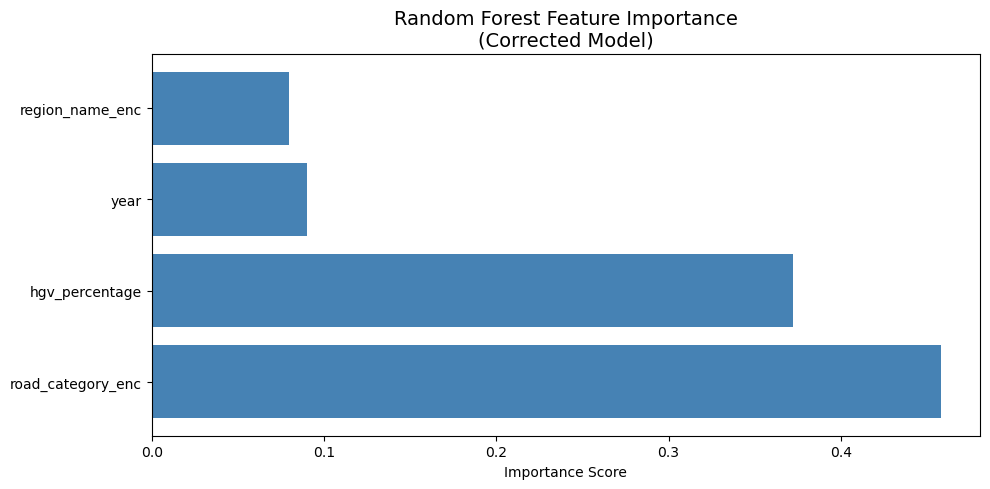


Top feature: road_category_enc
             Feature  Importance
2  road_category_enc    0.457769
1     hgv_percentage    0.372293
0               year    0.090059
3    region_name_enc    0.079878


In [15]:
# Cell 10 — Feature importance
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': corrected_features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,5))
plt.barh(importance['Feature'], 
         importance['Importance'],
         color='steelblue')
plt.title('Random Forest Feature Importance\n(Corrected Model)', 
          fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(r'C:\Users\dell\Desktop\FYP_Traffic\outputs\feature_importance_corrected.png')
plt.show()

print("\nTop feature:", importance.iloc[0]['Feature'])
print(importance)